In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
exo = pd.read_csv("exoplanet_data.csv", comment = "#")
exo.head()

,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,7 CMa c,7 CMa,0,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2024-09-13,2024-07,2024-09-13
1,7 CMa c,7 CMa,1,1,2,Radial Velocity,2019,Multiple Observatories,Published Confirmed,0,...,-0.03,1.564,0.252,-0.252,3.67853,0.004135,-0.004135,2019-10-18,2019-11,2019-10-24
2,DMPP-1 b,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05
3,DMPP-1 b,DMPP-1,0,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2020-01-23,2019-12,2020-01-30
4,DMPP-1 c,DMPP-1,1,1,4,Radial Velocity,2019,La Silla Observatory,Published Confirmed,0,...,-0.03,6.690,0.024,-0.024,7.85032,0.000290,-0.000290,2026-03-05,2026-02,2026-03-05


In [3]:
print(exo.shape)
print("Number of rows:", exo.shape[0])
print("Number of columns", exo.shape[1])
print(exo.columns.tolist())

(583, 92)
Number of rows: 583
Number of columns 92
['pl_name', 'hostname', 'default_flag', 'sy_snum', 'sy_pnum', 'discoverymethod', 'disc_year', 'disc_facility', 'soltype', 'pl_controv_flag', 'pl_refname', 'pl_orbper', 'pl_orbpererr1', 'pl_orbpererr2', 'pl_orbperlim', 'pl_orbsmax', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbsmaxlim', 'pl_rade', 'pl_radeerr1', 'pl_radeerr2', 'pl_radelim', 'pl_radj', 'pl_radjerr1', 'pl_radjerr2', 'pl_radjlim', 'pl_bmasse', 'pl_bmasseerr1', 'pl_bmasseerr2', 'pl_bmasselim', 'pl_bmassj', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_bmassjlim', 'pl_bmassprov', 'pl_orbeccen', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_orbeccenlim', 'pl_insol', 'pl_insolerr1', 'pl_insolerr2', 'pl_insollim', 'pl_eqt', 'pl_eqterr1', 'pl_eqterr2', 'pl_eqtlim', 'ttv_flag', 'st_refname', 'st_spectype', 'st_teff', 'st_tefferr1', 'st_tefferr2', 'st_tefflim', 'st_rad', 'st_raderr1', 'st_raderr2', 'st_radlim', 'st_mass', 'st_masserr1', 'st_masserr2', 'st_masslim', 'st_met', 'st_meterr1', 'st_m

5 column titles that I have no idea what they mean:
sy_snum, sy_pnum, pl_orbpererr1, sy_vmagerr1, sy_kmag

In [4]:
#Table Label: Planet Name
#Database Column Name: pl_name
#Description: Planet Name
#in my own words: the name of the exoplant

#Table Label: Host Name
#Database Column Name: hostname
#Description: Host Name
#in my own words: the name of the star that the planet orbits

#Table Label: Discovery Method
#Database Column Name: discoverymethod
#Description: Discovery Method
#in my own words: this shows how the planet was detected, such as transit or imaging.

#Table Label: Spectral Type
#Database Column Name: st_spectype
#Description: Spectral Type
#in my own words: this describe the type of the host star based on their surface temperature and spectral lines.

#Table Label: Equilibrium Temperature [K]
#Database Column Name: pl_eqt
#Description: Equilibrium Temperature [K]
#in my own words: this is the estimated temperature of the planet in kelvin

#Table Label: Planet Mass or Mass*sin(i) [Jupiter Mass]
#Database Column Name: pl_bmassj
#Description: Planet Mass or Mass*sin(i) [Jupiter Mass]
#in my own words: this gives the planet's mass, or mass times sin(i), measured in Jupiter masses.

In [5]:
small_exo = exo[[
    "pl_name",
    "hostname",
    "discoverymethod",
    "st_spectype",
    "pl_eqt",
    "pl_bmassj"
]]

In [6]:
small_exo = small_exo.dropna()

In [7]:
print(small_exo.shape)
print("Number of rows:", small_exo.shape[0])
print("Number of columns", small_exo.shape[1])
print(small_exo.columns.tolist())

(70, 6)
Number of rows: 70
Number of columns 6
['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj']


In [8]:
small_exo.head()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
3,DMPP-1 b,DMPP-1,Radial Velocity,F8 V,877.0,0.076362
5,DMPP-1 c,DMPP-1,Radial Velocity,F8 V,1239.0,0.030205
7,DMPP-1 d,DMPP-1,Radial Velocity,F8 V,1632.0,0.010540
8,DMPP-1 e,DMPP-1,Radial Velocity,F8 V,1314.0,0.012994
10,DMPP-2 b,DMPP-2,Radial Velocity,F5 V,1000.0,0.437000


In [9]:
small_exo.tail()

,pl_name,hostname,discoverymethod,st_spectype,pl_eqt,pl_bmassj
561,WASP-185 b,WASP-185,Transit,G0 V,1160.0,0.980
565,WASP-190 b,WASP-190,Transit,F6 IV-V,1500.0,1.000
569,WASP-192 b,WASP-192,Transit,G0 V,1620.0,2.300
572,XO-7 b,XO-7,Transit,G0 V,1743.0,0.709
581,eps Ind A b,eps Ind A,Radial Velocity,K5 V,275.0,6.310


In [10]:
discovery_counts = small_exo["discoverymethod"].value_counts()
print(discovery_counts)

discoverymethod
Transit            55
Radial Velocity    13
Imaging             2
Name: count, dtype: int64


The discovery methods in my smaller dataset are Transit, Radial Velocity, and Imaging. There are 55 planets discovered by Transit, 13 by Radial velocity, and 2 by imaging. The transit method has the most planets, and imaging has the least. Transit means a planets is detected when it passes in front of its star and causes the detection of the star's light to dim. Radial velocity means a planet is detected from the small motion it causes in its host star. Imaging means a planet is found by directly taking picture of it. 

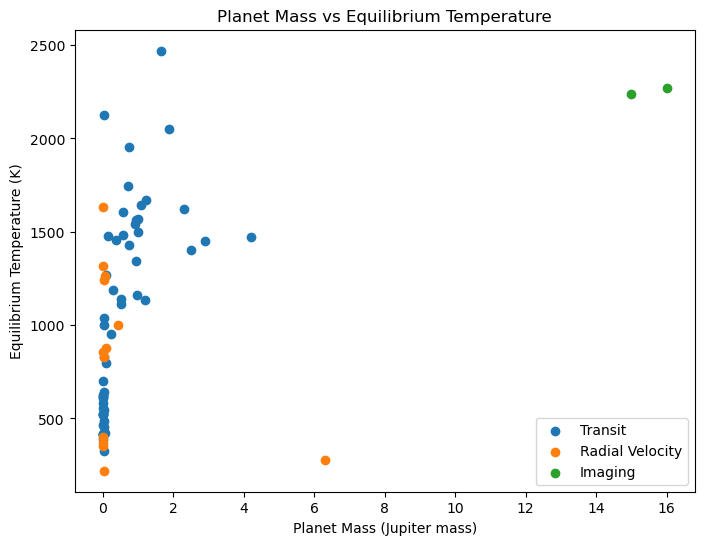

In [11]:
plt.figure(figsize = (8, 6))

transit = small_exo[small_exo["discoverymethod"] == "Transit"]
radial_velocity = small_exo[small_exo["discoverymethod"] == "Radial Velocity"]
imaging = small_exo[small_exo["discoverymethod"] == "Imaging"]

plt.scatter(transit["pl_bmassj"], transit["pl_eqt"], label = "Transit")
plt.scatter(radial_velocity["pl_bmassj"], radial_velocity["pl_eqt"], label = "Radial Velocity")
plt.scatter(imaging["pl_bmassj"], imaging["pl_eqt"], label = "Imaging")

plt.title("Planet Mass vs Equilibrium Temperature")
plt.xlabel("Planet Mass (Jupiter mass)")
plt.ylabel("Equilibrium Temperature (K)")
plt.legend()
plt.show()

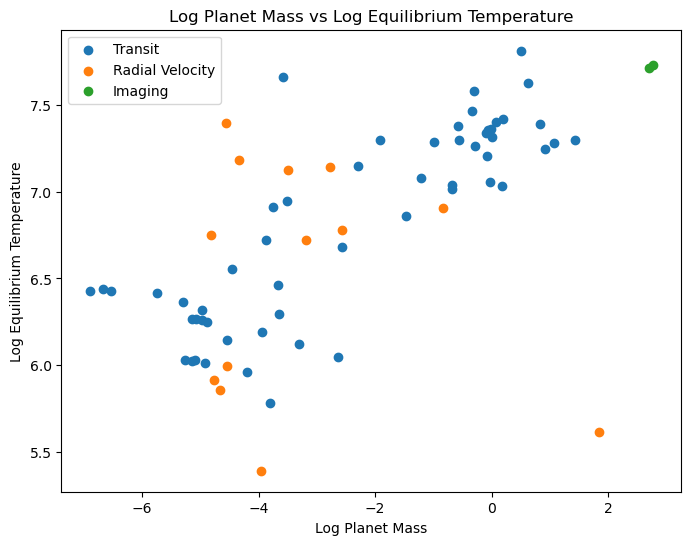

In [12]:
plt.figure(figsize = (8, 6))

transit = small_exo[small_exo["discoverymethod"] == "Transit"]
radial_velocity = small_exo[small_exo["discoverymethod"] == "Radial Velocity"]
imaging = small_exo[small_exo["discoverymethod"] == "Imaging"]

plt.scatter(np.log(transit["pl_bmassj"]), np.log(transit["pl_eqt"]), label = "Transit")
plt.scatter(np.log(radial_velocity["pl_bmassj"]), np.log(radial_velocity["pl_eqt"]), label = "Radial Velocity")
plt.scatter(np.log(imaging["pl_bmassj"]), np.log(imaging["pl_eqt"]), label = "Imaging")

plt.title("Log Planet Mass vs Log Equilibrium Temperature")
plt.xlabel("Log Planet Mass")
plt.ylabel("Log Equilibrium Temperature")
plt.legend()
plt.show()

As shown in the graph, exoplanets found by the imaging method are more likely to be massive.

The coldest planet with a mass larger than five Jupiter Masses seems to be the stars that has about 6 Jupiter masses and temperature about 250K in the graph.

In [13]:
planets_mass_larger_5JupiterMass = small_exo[small_exo["pl_bmassj"] > 5]
coldest = planets_mass_larger_5JupiterMass.loc[planets_mass_larger_5JupiterMass["pl_eqt"].idxmin()]

In [14]:
print("Name:", coldest["pl_name"])
print("Index:", coldest.name)
print("Equilibrium temperature:", coldest["pl_eqt"])
print("Mass (Jupiter masses):", coldest["pl_bmassj"])
print("Host star spectral type:", coldest["st_spectype"])

Name: eps Ind A b
Index: 581
Equilibrium temperature: 275.0
Mass (Jupiter masses): 6.31
Host star spectral type: K5 V


It is not a sun-like star. The Sun is a G-type star, while this host star is K5 V, which is cooler.

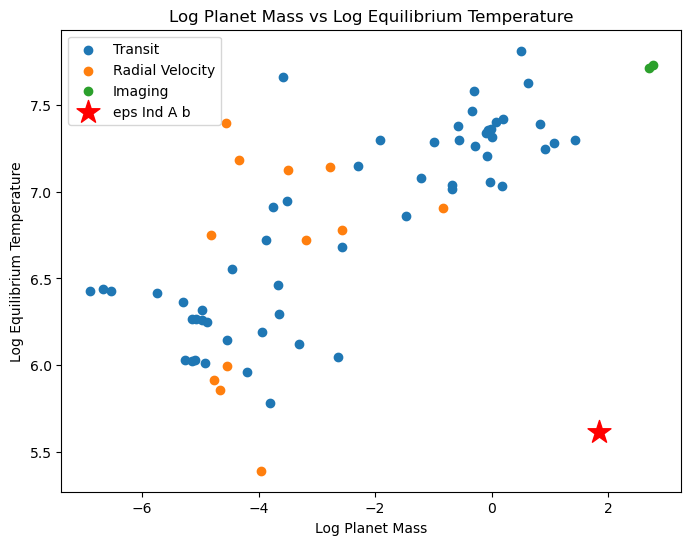

In [15]:
plt.figure(figsize = (8, 6))

transit = small_exo[small_exo["discoverymethod"] == "Transit"]
radial_velocity = small_exo[small_exo["discoverymethod"] == "Radial Velocity"]
imaging = small_exo[small_exo["discoverymethod"] == "Imaging"]

plt.scatter(np.log(transit["pl_bmassj"]), np.log(transit["pl_eqt"]), label = "Transit")
plt.scatter(np.log(radial_velocity["pl_bmassj"]), np.log(radial_velocity["pl_eqt"]), label = "Radial Velocity")
plt.scatter(np.log(imaging["pl_bmassj"]), np.log(imaging["pl_eqt"]), label = "Imaging")

plt.scatter(
    np.log(coldest["pl_bmassj"]),
    np.log(coldest["pl_eqt"]),
    color = "red",
    marker = "*",
    s = 300,
    label = coldest["pl_name"]
)

plt.title("Log Planet Mass vs Log Equilibrium Temperature")
plt.xlabel("Log Planet Mass")
plt.ylabel("Log Equilibrium Temperature")
plt.legend()
plt.show()

What is the title of this paper?
A temperate super-Jupiter imaged with JWST in the mid-infrared

Summarize the abstract to the best of your ability in your own words.
In the abstract, the researchers explain that JWST diretly image a giant planet around Eps Ind A. They found that the planet is much colder than most directly imaged exoplanets, and it is bright in the mid-infrared. They also says that the planet's properties are different from earlier studies had predicted and suggest that it may have unusual atmospheric chemistry. 

Does your answer match the exoplanet?
Yes. 

What is special about the planet you found?
This planet has a very unusual temperature 275K, which is cool for a directly imaged planet.

Do the mass and equilibrium temperature match what the paper reported? If not, what are the differences?
The mass and equilibrium temperature match with what I found. 